In [1]:
# Import libraries and magicsim
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets
import tensorflow_io
import librosa

2026-04-21 18:18:18.724568: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 18:18:18.732303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776809898.742015 1831605 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776809898.745293 1831605 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-21 18:18:18.755806: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
data = np.load("training_data_eee4773.npy").T
labels = np.load("training_labels_eee4773.npy")

X_train, X_test, t_train, t_test = train_test_split(data, labels, test_size=0.2, random_state=0, stratify=labels)
X_train.shape

X_train_16k = np.array([librosa.resample(x, orig_sr=48000, target_sr=16000) for x in X_train])
X_test_16k = np.array([librosa.resample(x, orig_sr=48000, target_sr=16000) for x in X_test])
X_train_16k, X_val_16k, t_train, t_val = train_test_split(X_train_16k, t_train, test_size=0.15, random_state=0, stratify=t_train)


In [3]:
training_speech, validation_speech = tensorflow_datasets.load("speech_commands", split=["train", "validation"], as_supervised=True)

2026-04-21 18:18:28.231429: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [4]:
def preprocess(audio, label):
    audio = tf.cast(audio, tf.float32) / 32768.0
    audio = tf.reshape(audio, [-1])
    
    current_length = tf.shape(audio)[0]
    pad_total = tf.maximum(48000 - current_length, 0)
    pad_left = tf.random.uniform([], 0, pad_total + 1, dtype=tf.int32)
    pad_right = pad_total - pad_left
    
    audio = tf.pad(audio, [[pad_left, pad_right]])
    audio = audio[:48000]
    
    return audio, label


training_speech = (
    training_speech
    .map(preprocess)
    .shuffle(1000)
    .batch(64)
)

validation_speech = (
    validation_speech
    .map(preprocess)
    .batch(64)
)

In [5]:
conv_encoder = keras.models.Sequential([
    keras.Input(shape=(48000,)),
    
    keras.layers.MelSpectrogram(fft_length=512,
                               sequence_stride=160,
                               sampling_rate=16000,
                               num_mel_bins=80,
                               min_freq=80,
                               power_to_db=True),
    
    keras.layers.Reshape((80, 301, 1)),
    
    keras.layers.Conv2D(filters=32,kernel_size=3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(pool_size=2, padding="same"),
    
    keras.layers.Conv2D(filters=64,kernel_size=3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(pool_size=2, padding="same"),
    
    keras.layers.Conv2D(filters=128,kernel_size=3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(pool_size=2, padding="same"),
])

conv_encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_spectrogram                 │ (None, 80, 301)        │             0 │
│ (MelSpectrogram)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 80, 301, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 80, 301, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 151, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 151, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 76, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 76, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 38, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
inp = keras.layers.Input(shape=(48000,))

x = conv_encoder(inp)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(500, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
out = keras.layers.Dense(12, activation="softmax")(x)
#there is 12 classes in this 



encoder_classifier = keras.models.Model(inp, out)


encoder_classifier.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=["accuracy"])

stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

In [7]:
history = encoder_classifier.fit(training_speech, validation_data=validation_speech, epochs=10, callbacks=[stopping])

Epoch 1/10


2026-04-21 18:18:29.331743: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:376] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


1337/1337 ━━━━━━━━━━━━━━━━━━━━ 227s 169ms/step - accuracy: 0.6399 - loss: 3.5996 - val_accuracy: 0.8469 - val_loss: 0.4827
Epoch 2/10
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 226s 169ms/step - accuracy: 0.8184 - loss: 0.5525 - val_accuracy: 0.8990 - val_loss: 0.3186
Epoch 3/10
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 229s 171ms/step - accuracy: 0.8620 - loss: 0.4199 - val_accuracy: 0.9117 - val_loss: 0.2763
Epoch 4/10
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 234s 175ms/step - accuracy: 0.8855 - loss: 0.3538 - val_accuracy: 0.9305 - val_loss: 0.2350
Epoch 5/10
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 231s 172ms/step - accuracy: 0.8978 - loss: 0.3166 - val_accuracy: 0.9348 - val_loss: 0.2107
Epoch 6/10
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 234s 175ms/step - accuracy: 0.9057 - loss: 0.2938 - val_accuracy: 0.9354 - val_loss: 0.2146
Epoch 7/10
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 237s 177ms/step - accuracy: 0.9128 - loss: 0.2783 - val_accuracy: 0.9436 - val_loss: 0.1862
Epoch 8/10
1337/1337 ━━━━━━━━━━━━━━━━━━━━ 234s 175ms/step - accuracy: 0.9

In [8]:
conv_encoder.save_weights("encoder_weights_from_google_set.weights.h5")

In [9]:
conv_encoder.load_weights("encoder_weights_from_google_set.weights.h5")

for layer in conv_encoder.layers:
        layer.trainable = True
inp = keras.layers.Input(shape=(48000,))

x = conv_encoder(inp)
x = keras.layers.Flatten()(x)

x = keras.layers.Dropout(0.5)(x)

x = keras.layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)

x = keras.layers.Dropout(0.5)(x)
out = keras.layers.Dense(1, activation='sigmoid')(x)

clf = keras.models.Model(inp, out)
clf.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 10, 38, 128)    │        92,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 48640)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48640)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │     1,556,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,649,217 (6.29 MB)

 Trainable params: 1,649,217 (6.29 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
clf.compile(loss='binary_crossentropy',
              optimizer="adam",
              metrics=["accuracy"])

stopping = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)


history = clf.fit(X_train_16k, t_train, epochs=30, batch_size=32, validation_data=(X_val_16k, t_val), callbacks=[stopping])

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.9777 - loss: 0.0687 - val_accuracy: 0.7045 - val_loss: 0.9370
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9846 - loss: 0.0735 - val_accuracy: 0.7727 - val_loss: 0.7265
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9980 - loss: 0.0510 - val_accuracy: 0.7955 - val_loss: 0.9237
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9944 - loss: 0.0462 - val_accuracy: 0.7727 - val_loss: 0.9846
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9950 - loss: 0.0399 - val_accuracy: 0.7273 - val_loss: 0.9540
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 1.0000 - loss: 0.0326 - val_accuracy: 0.7727 - val_loss: 1.0096
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9922 - loss: 0.0382 - val_accuracy: 0.7955 - val_loss: 1.0388


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


0.7692307692307693

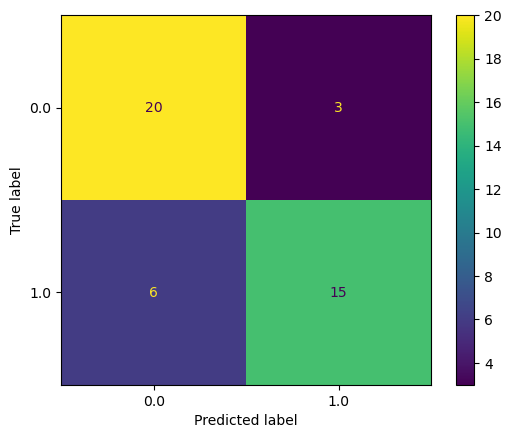

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

y_pred = clf.predict(X_val_16k)
y_pred = (y_pred > 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(t_val, y_pred)
f1_score(t_val, y_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


0.8985507246376812

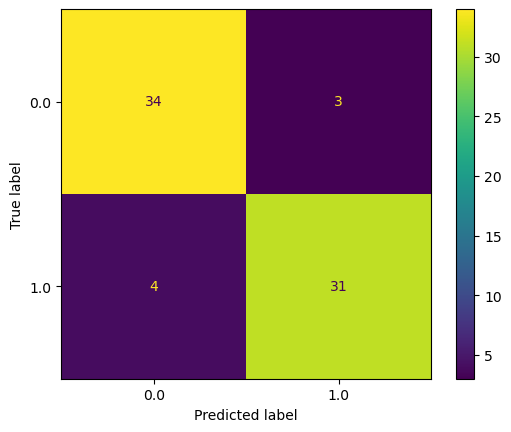

In [16]:
y_pred = clf.predict(X_test_16k)
y_pred = (y_pred > 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(t_test, y_pred)
f1_score(t_test, y_pred)

In [13]:
clf.save("final_model.keras")